# Match-Level Analysis - How ODI Batting Has Evolved Over The Years

## 1. Data Loading

In [3]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)


import os

In [4]:
# Path to project root (one level up from the notebook folder)
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

DATA_PATH = '/Users/sarimkhalil/Desktop/Programming/Case Study On Cricket/data/'

# Load datasets
df_asiacup = pd.read_csv(os.path.join(DATA_PATH, 'asiacup.csv'))
df_batsman = pd.read_csv(os.path.join(DATA_PATH, 'batsman data odi.csv'))
df_bowler = pd.read_csv(os.path.join(DATA_PATH, 'bowler data odi.csv'))
df_champion = pd.read_csv(os.path.join(DATA_PATH, 'champion.csv'))
df_wicketkeeper = pd.read_csv(os.path.join(DATA_PATH, 'wicketkeeper data odi.csv'))

for name, df in [
    ('asiacup.csv', df_asiacup),
    ('batsman_data_odi.csv', df_batsman),
    ('bowler_data_odi.csv', df_bowler),
    ('champion.csv', df_champion),
    ('wicketkeeper_data_odi.csv', df_wicketkeeper),
]:
    print(f"Loaded {name}: {df.shape[0]} rows, {df.shape[1]} columns")


Loaded asiacup.csv: 254 rows, 20 columns
Loaded batsman_data_odi.csv: 50 rows, 16 columns
Loaded bowler_data_odi.csv: 45 rows, 15 columns
Loaded champion.csv: 15 rows, 8 columns
Loaded wicketkeeper_data_odi.csv: 40 rows, 9 columns


In [5]:
print("asiacup.csv Overview")
print(f"\nShape: {df_asiacup.shape}")
print(f"\nColumns:\n{df_asiacup.columns.tolist()}")
df_asiacup.head()

asiacup.csv Overview

Shape: (254, 20)

Columns:
['Team', 'Opponent', 'Format', 'Ground', 'Year', 'Toss', 'Selection', 'Run Scored', 'Wicket Lost', 'Fours', 'Sixes', 'Extras', 'Run Rate', 'Avg Bat Strike Rate', 'Highest Score', 'Wicket Taken', 'Given Extras', 'Highest Individual wicket', 'Player Of The Match', 'Result']


,Team,Opponent,Format,Ground,Year,Toss,Selection,Run Scored,Wicket Lost,Fours,Sixes,Extras,Run Rate,Avg Bat Strike Rate,Highest Score,Wicket Taken,Given Extras,Highest Individual wicket,Player Of The Match,Result
0,Pakistan,Sri Lanka,ODI,Sharjah,1984,Lose,Batting,187.00,9.00,9.00,3.00,21.00,4.06,52.04,47.00,5.00,26.00,2.00,Roy Dias,Lose
1,Sri Lanka,Pakistan,ODI,Sharjah,1984,Win,Bowling,190.00,5.00,11.00,1.00,26.00,4.36,68.51,57.00,9.00,21.00,3.00,Roy Dias,Win
2,India,Sri Lanka,ODI,Sharjah,1984,Win,Bowling,97.00,0.00,9.00,0.00,14.00,4.47,60.48,51.00,10.00,8.00,3.00,Surinder Khanna,Win
3,Sri Lanka,India,ODI,Sharjah,1984,Lose,Batting,96.00,10.00,7.00,0.00,8.00,2.34,25.74,38.00,0.00,14.00,0.00,Surinder Khanna,Lose
4,India,Pakistan,ODI,Sharjah,1984,Win,Batting,188.00,4.00,13.00,3.00,17.00,4.08,60.21,56.00,10.00,5.00,3.00,Surinder Khanna,Win


Distribution of Match Formats:
Format
ODI     206
T20I     48
Name: count, dtype: int64
Saved: ../images/graph_01.png


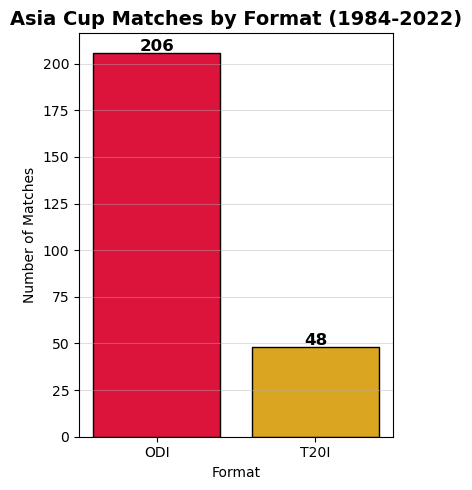

In [6]:
# format distribution
print("Distribution of Match Formats:")
format_counts = df_asiacup['Format'].value_counts()
print(format_counts)

# Visualise using bar chart
plt.figure(figsize=(4, 5))

plt.bar(format_counts.index, format_counts.values,
        color=['crimson', 'goldenrod'],
        edgecolor='black')

plt.title('Asia Cup Matches by Format (1984-2022)', fontsize=14, fontweight='bold')
plt.xlabel('Format')
plt.ylabel('Number of Matches')
plt.grid(axis='y', alpha=0.4)

for index, values in enumerate(format_counts.values):
    plt.text(index, values + 1, str(values), fontsize=12, fontweight='bold', ha='center')

plt.tight_layout()
plt.show()


In [7]:
# Key insight 
odi_matches = format_counts['ODI']
odi_percentage = odi_matches / format_counts.sum() * 100
print(f"ODI format dominates with {odi_matches} matches ({odi_percentage:.1f}%).")

ODI format dominates with 206 matches (81.1%).


This provides us with a dense enough data to hold our analysis.

In [9]:
# Filter asiacup dataset for ODI matches only
df_odi_matches = df_asiacup[df_asiacup['Format'] == 'ODI'].copy()

# Check if filtered properly
print(f"ODI matches: {len(df_odi_matches)} matches")

# Check ODI matches by year
print("ODI Matches by Year:")
year_distribution = df_odi_matches['Year'].value_counts().sort_index()
print(year_distribution)

print(f"\nTime Span: {df_odi_matches['Year'].min()} to {df_odi_matches['Year'].max()} ({df_odi_matches['Year'].max() - df_odi_matches['Year'].min()} years)")
print(f"Tournament Years: {df_odi_matches['Year'].nunique()} unique years")
print(f"Average matches per tournament: {len(df_odi_matches) / df_odi_matches['Year'].nunique():.1f}")

ODI matches: 206 matches
ODI Matches by Year:
Year
1984     6
1986     8
1988    14
1990     6
1991     2
1995    14
1997    14
2000    14
2004    26
2008    26
2010    14
2012    14
2014    22
2018    26
Name: count, dtype: int64

Time Span: 1984 to 2018 (34 years)
Tournament Years: 14 unique years
Average matches per tournament: 14.7


Saved: ../images/graph_02.png


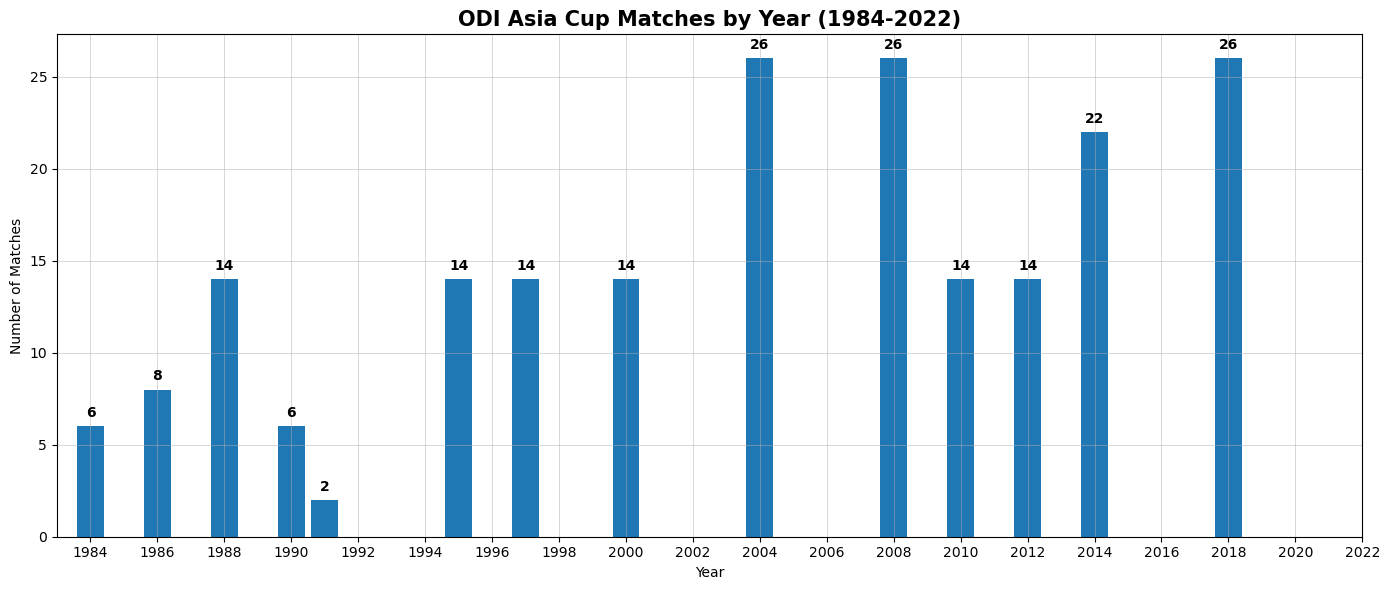

In [10]:
# Visualize ODI matches over time
plt.figure(figsize=(14, 6))
plt.bar(year_distribution.index, year_distribution.values)
plt.title('ODI Asia Cup Matches by Year (1984-2022)', fontsize=15, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Matches')
plt.xticks(year_distribution.index)

# Set x-axis to show ALL years from 1984 to 2022
plt.xlim(1983, 2022) 
plt.xticks(range(1984, 2023, 2))  # Show every 2 years

# Enable gridlines 
plt.grid(axis='both', alpha=0.7, linewidth=0.5)

# Add value labels on bars
for year, count in year_distribution.items():
    plt.text(year, count + 0.5, str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


Tournament size increased significantly over time, especially post-2000 era, with larger tournaments becoming the norm.

## 2. Data Cleaning

In [13]:
# Check missing values in ODI match data
print("Missing Values in ODI Match Data:")

missing = df_odi_matches.isnull().sum()
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing Count': missing.values,
    'Missing %': (missing.values / len(df_odi_matches) * 100).round(2) # pct of missing data
})

# show missing data
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

if len(missing_df) > 0:
    print(missing_df.to_string(index=False))
    print(f"\nTotal columns with missing values: {len(missing_df)}")
else:
    print("No missing values in the data")

Missing Values in ODI Match Data:
                   Column  Missing Count  Missing %
               Run Scored              2       0.97
              Wicket Lost              2       0.97
                    Fours              2       0.97
                    Sixes              2       0.97
                   Extras              2       0.97
                 Run Rate              2       0.97
      Avg Bat Strike Rate              2       0.97
            Highest Score              2       0.97
             Wicket Taken              2       0.97
             Given Extras              2       0.97
Highest Individual wicket              2       0.97
      Player Of The Match              2       0.97

Total columns with missing values: 12


In [14]:
# Handle missing values if any
print("Handling Missing Values:")

# Check which rows have missing values
rows_with_missing = df_odi_matches[df_odi_matches.isnull().any(axis=1)]
print(f"Rows with any missing values: {len(rows_with_missing)}")

if len(rows_with_missing) > 0:
    print("\nRows with missing data:")
    print(rows_with_missing[['Team', 'Opponent', 'Year', 'Run Scored', 'Avg Bat Strike Rate']])
    
    # Drop rows with missing critical values 
    print(f"\nDropping {len(rows_with_missing)} rows with missing critical data")
    df_odi_matches = df_odi_matches.dropna(subset=['Run Scored', 'Avg Bat Strike Rate', 'Run Rate'])
    print(f"Remaining ODI matches: {len(df_odi_matches)}")
else:
    print("No missing values to handle")

Handling Missing Values:
Rows with any missing values: 2

Rows with missing data:
        Team  Opponent  Year  Run Scored  Avg Bat Strike Rate
56     India  Pakistan  1997         NaN                  NaN
57  Pakistan     India  1997         NaN                  NaN

Dropping 2 rows with missing critical data
Remaining ODI matches: 204


In [15]:
# Check data types
print("Data Types in ODI Match Data:")
print(df_odi_matches.dtypes)

# Verify numeric columns
numeric_cols = ['Run Scored', 'Wicket Lost', 'Fours', 'Sixes', 'Run Rate', 'Avg Bat Strike Rate']

Data Types in ODI Match Data:
Team                          object
Opponent                      object
Format                        object
Ground                        object
Year                           int64
Toss                          object
Selection                     object
Run Scored                   float64
Wicket Lost                  float64
Fours                        float64
Sixes                        float64
Extras                       float64
Run Rate                     float64
Avg Bat Strike Rate          float64
Highest Score                float64
Wicket Taken                 float64
Given Extras                 float64
Highest Individual wicket    float64
Player Of The Match           object
Result                        object
dtype: object


All key numeric columns have correct data types.

In [17]:
# Check for any data quality issues
print("Data Quality Checks:")

print(f"Negative values in 'Run Scored': {(df_odi_matches['Run Scored'] < 0).sum()}")
print(f"Negative wickets: {(df_odi_matches['Wicket Lost'] < 0).sum()}")
print(f"Wickets > 10: {(df_odi_matches['Wicket Lost'] > 10).sum()}")

Data Quality Checks:
Negative values in 'Run Scored': 0
Negative wickets: 0
Wickets > 10: 0


No anomalies detected.

## 3. Feature Engineering

Era Distribution in ODI Matches:
Era
Early Era (1984-1995)     50
Middle Era (1996-2008)    78
Modern Era (2009-2018)    76
Name: count, dtype: int64
Saved: ../images/graph_03.png


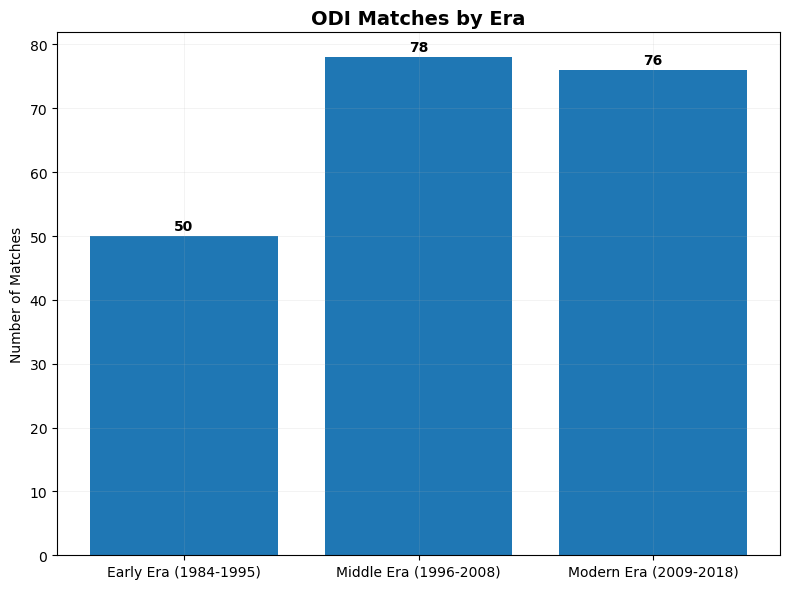

In [20]:
# Create era classification function
def era_assign(year):
    """
    Assign cricket era based on year.

    Early Era (1984–1995): Pre-modern ODI cricket
    Middle Era (1996–2008): Rise of aggressive batting
    Modern Era (2009–2018): T20 influence on ODI cricket
    """
    if year <= 1995:
        return 'Early Era (1984-1995)'
    elif year <= 2008:
        return 'Middle Era (1996-2008)'
    else:
        return 'Modern Era (2009-2018)'


# Applying the era classification
df_odi_matches['Era'] = df_odi_matches['Year'].apply(era_assign)

# Create numeric era encoding (for correlation / trend analysis)
era_mapping = {
    'Early Era (1984-1995)': 1,
    'Middle Era (1996-2008)': 2,
    'Modern Era (2009-2018)': 3
}
df_odi_matches['Era_Numeric'] = df_odi_matches['Era'].map(era_mapping)

# Display era distribution
print("Era Distribution in ODI Matches:")
era_distribution = df_odi_matches['Era'].value_counts().sort_index()
print(era_distribution)

# Visualising using a Bar Chart 
plt.figure(figsize=(8, 6))

plt.bar(
    era_distribution.index,
    era_distribution.values
)

plt.ylabel('Number of Matches')
plt.title('ODI Matches by Era', fontsize=14, fontweight='bold')

# Enable gridlines 
plt.grid(axis='both', alpha=0.2, linewidth=0.5)

# Add value labels on bars
for index, value in enumerate(era_distribution.values):
    plt.text(index, value + 1, str(value), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()



Era classification and distribution visualisation done

In [22]:
# Calculate boundary-related metrics
print("Calculate Boundary Metrics\n")

# Calculate total runs obtained from boundaries
df_odi_matches['Boundary_Runs'] = (df_odi_matches['Fours'] * 4) + (df_odi_matches['Sixes'] * 6)

# Calculate percentage of total runs from boundaries
df_odi_matches['Boundary_Percentage'] = (df_odi_matches['Boundary_Runs'] / df_odi_matches['Run Scored'] * 100).round(2)

# Calculate ixes to fours ratio
df_odi_matches['Sixes_to_Fours_Ratio'] = (df_odi_matches['Sixes'] / (df_odi_matches['Fours'] + 1)).round(3)

# Calculate total number of boundaries
df_odi_matches['Total_Boundaries'] = df_odi_matches['Fours'] + df_odi_matches['Sixes']

# Calculate non-boundary runs 
df_odi_matches['Non_Boundary_Runs'] = df_odi_matches['Run Scored'] - df_odi_matches['Boundary_Runs']

print("\nSample of new features:")
df_odi_matches[['Team', 'Year', 'Era', 'Run Scored', 'Fours', 'Sixes', 
                'Boundary_Runs', 'Boundary_Percentage', 'Sixes_to_Fours_Ratio','Total_Boundaries','Non_Boundary_Runs' ]].head()

Calculate Boundary Metrics


Sample of new features:


,Team,Year,Era,Run Scored,Fours,Sixes,Boundary_Runs,Boundary_Percentage,Sixes_to_Fours_Ratio,Total_Boundaries,Non_Boundary_Runs
0,Pakistan,1984,Early Era (1984-1995),187.00,9.00,3.00,54.00,28.88,0.30,12.00,133.00
1,Sri Lanka,1984,Early Era (1984-1995),190.00,11.00,1.00,50.00,26.32,0.08,12.00,140.00
2,India,1984,Early Era (1984-1995),97.00,9.00,0.00,36.00,37.11,0.00,9.00,61.00
3,Sri Lanka,1984,Early Era (1984-1995),96.00,7.00,0.00,28.00,29.17,0.00,7.00,68.00
4,India,1984,Early Era (1984-1995),188.00,13.00,3.00,70.00,37.23,0.21,16.00,118.00


Created 5 boundary-related metrics:

1. Boundary_Runs  
2. Boundary_Percentage (normalised metric)  
3. Sixes_to_Fours_Ratio  
4. Total_Boundaries  
5. Non_Boundary_Runs


In [24]:
# Additional scoring metrics
print("Calculating further Scoring Rate Metrics")

# Run rate category
def Run_Rate_Speed(run_rate):
    """Function to categorise run rate"""
    if run_rate < 4.0:
        return 'Slow (< 4.0)'
    elif run_rate < 5.0:
        return 'Moderate (4.0-5.0)'
    elif run_rate < 6.0:
        return 'Fast (5.0-6.0)'
    else:
        return 'Very Fast (6.0+)'

df_odi_matches['Run_Rate_Speed'] = df_odi_matches['Run Rate'].apply(Run_Rate_Speed)

print("\nRun Rate Distribution:")
print(df_odi_matches['Run_Rate_Speed'].value_counts().sort_index())

Calculating further Scoring Rate Metrics

Run Rate Distribution:
Run_Rate_Speed
Fast (5.0-6.0)        60
Moderate (4.0-5.0)    67
Slow (< 4.0)          47
Very Fast (6.0+)      30
Name: count, dtype: int64


Created a new run rate metric to help catogirise an innings run rate and use it for comparisons and analysis

## 4. Statistical Summary

In [27]:
# Calculate summary statistics by era

summary_by_era = df_odi_matches.groupby('Era').agg({
    'Run Scored': ['mean', 'median', 'std'],
    'Avg Bat Strike Rate': ['mean', 'median', 'std'],
    'Fours': ['mean', 'median'],
    'Sixes': ['mean', 'median'],
    'Boundary_Percentage': ['mean', 'median'],
    'Run Rate': ['mean', 'median']
}).round(2)

summary_by_era

Run Scored              Avg Bat Strike Rate         \
                             mean median   std                mean median   
Era                                                                         
Early Era (1984-1995)      173.10 178.00 49.41               59.01  58.24   
Middle Era (1996-2008)     228.78 238.00 68.24               73.59  73.23   
Modern Era (2009-2018)     233.92 245.50 55.03               75.02  73.53   

                             Fours        Sixes        Boundary_Percentage  \
                         std  mean median  mean median                mean   
Era                                                                          
Early Era (1984-1995)  21.74  8.88   9.00  1.20   1.00               23.86   
Middle Era (1996-2008) 27.15 19.17  18.50  2.51   2.00               39.42   
Modern Era (2009-2018) 23.85 19.05  19.00  3.54   3.00               41.14   

                              Run Rate         
                       median     mean median  
Era                                            
Early Era (1984-1995)   25.64     4.20   4.14  
Middle Era (1996-2008)  38.72     5.04   5.06  
Modern Era (2009-2018)  39.92     5.03   5.03

In [28]:
# Calculate and display percentage changes
print("Evolution between the different eras")

# Get mean values for each era
early_stats = df_odi_matches[df_odi_matches['Era'] == 'Early Era (1984-1995)'].agg({
    'Run Scored': 'mean',
    'Avg Bat Strike Rate': 'mean',
    'Fours': 'mean',
    'Sixes': 'mean',
    'Boundary_Percentage': 'mean'
})

modern_stats = df_odi_matches[df_odi_matches['Era'] == 'Modern Era (2009-2018)'].agg({
    'Run Scored': 'mean',
    'Avg Bat Strike Rate': 'mean',
    'Fours': 'mean',
    'Sixes': 'mean',
    'Boundary_Percentage': 'mean'
})

# Calculate percentage changes
for metric in early_stats.index:
    early_val = early_stats[metric]
    modern_val = modern_stats[metric]
    pct_change = ((modern_val - early_val) / early_val * 100)
    direction = "up by" if pct_change > 0 else "down by"
    print(f"{metric:20s}: {early_val:6.2f} to {modern_val:6.2f} {direction} {abs(pct_change):5.2f}%")


Evolution between the different eras
Run Scored          : 173.10 to 233.92 up by 35.14%
Avg Bat Strike Rate :  59.01 to  75.02 up by 27.13%
Fours               :   8.88 to  19.05 up by 114.56%
Sixes               :   1.20 to   3.54 up by 194.96%
Boundary_Percentage :  23.86 to  41.14 up by 72.44%


As we can see there has been a great evolution in aggression over the course of 34 years

## 5. Visualisation

### Visualisation Methodology
**Distribution Plots**: Frequency distribution curves showing the data spread and density for each era. Y-axis values represent estimated frequency derived from a scaled Gaussian KDE, and are best interpreted for comparative shape and relative distribution rather than exact counts.

**Box Plots**: Illustrating the statistical distribution, with outliers represented as individual dots.

**Outlier Detection**: Outliers are identified using the IQR (Interquartile Range) method, if it falls beyond $1.5 \times \text{IQR}$ from the first ($Q_1$) or third ($Q_3$) quartile.

Saved: ../images/graph_04.png


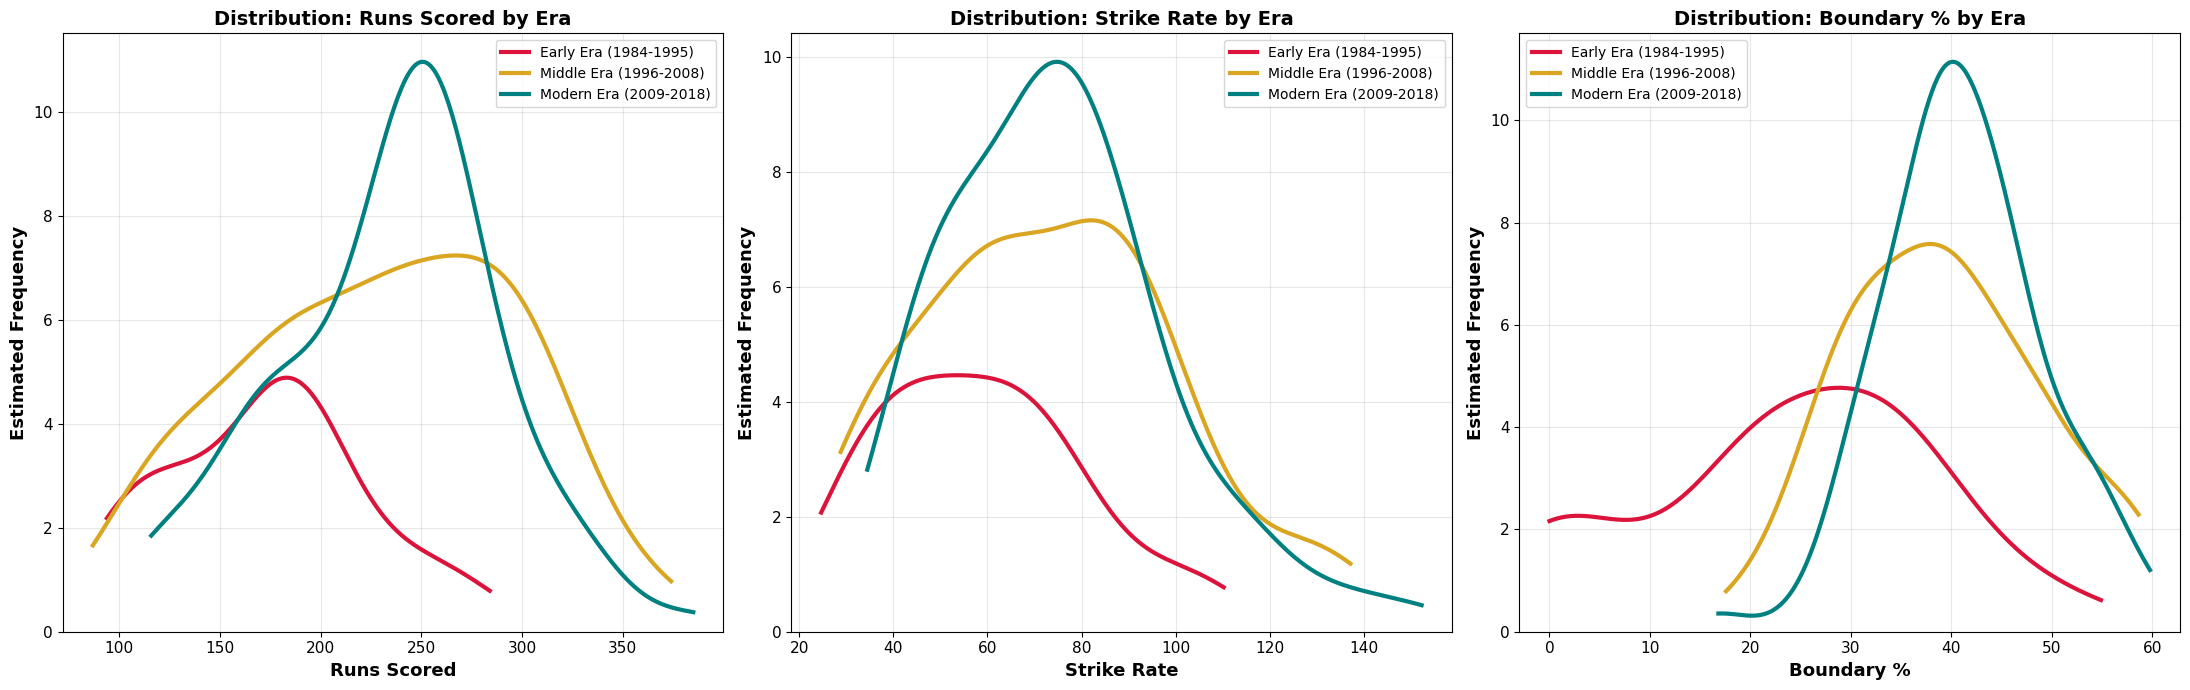

In [32]:
# Distribution Plots 
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

era_colors = {
    'Early Era (1984-1995)': 'crimson',
    'Middle Era (1996-2008)': 'goldenrod',
    'Modern Era (2009-2018)': 'teal'
}

era_order = ['Early Era (1984-1995)', 'Middle Era (1996-2008)', 'Modern Era (2009-2018)']

# Plot 1: Runs Scored Distribution
for era in era_order:
    data = df_odi_matches[df_odi_matches['Era'] == era]['Run Scored']
    counts, bins, patches = axes[0].hist(data, alpha=0, bins=15, density=True)
    x_smooth = np.linspace(data.min(), data.max(), 300)
    density = stats.gaussian_kde(data)
    y_smooth = density(x_smooth) * len(data) * (bins[1] - bins[0])
    axes[0].plot(x_smooth, y_smooth, color=era_colors[era], linewidth=3, label=era)

axes[0].set_xlabel('Runs Scored', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Estimated Frequency', fontsize=13, fontweight='bold')
axes[0].set_title('Distribution: Runs Scored by Era', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].tick_params(labelsize=11)

# Plot 2: Strike Rate Distribution
for era in era_order:
    data = df_odi_matches[df_odi_matches['Era'] == era]['Avg Bat Strike Rate']
    counts, bins, patches = axes[1].hist(data, alpha=0, bins=15, density=True)
    x_smooth = np.linspace(data.min(), data.max(), 300)
    density = stats.gaussian_kde(data)
    y_smooth = density(x_smooth) * len(data) * (bins[1] - bins[0])
    axes[1].plot(x_smooth, y_smooth, color=era_colors[era], linewidth=3, label=era)

axes[1].set_xlabel('Strike Rate', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Estimated Frequency', fontsize=13, fontweight='bold')
axes[1].set_title('Distribution: Strike Rate by Era', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)
axes[1].tick_params(labelsize=11)

# Plot 3: Boundary Percentage
for era in era_order:
    data = df_odi_matches[df_odi_matches['Era'] == era]['Boundary_Percentage']
    counts, bins, patches = axes[2].hist(data, alpha=0, bins=15, density=True)
    x_smooth = np.linspace(data.min(), data.max(), 300)
    density = stats.gaussian_kde(data)
    y_smooth = density(x_smooth) * len(data) * (bins[1] - bins[0])
    axes[2].plot(x_smooth, y_smooth, color=era_colors[era], linewidth=3, label=era)

axes[2].set_xlabel('Boundary %', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Estimated Frequency', fontsize=13, fontweight='bold')
axes[2].set_title('Distribution: Boundary % by Era', fontsize=14, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(alpha=0.3)
axes[2].tick_params(labelsize=11)

plt.tight_layout()
plt.show()

## Distribution Analysis

The kernel density plots reveal not just where performance shifted, but how *consistently* it did so.


### Runs Scored

There is a clear rightward shift in scoring across eras, but the more telling story is the change in distributional shape.

The **Early Era** distribution is broad and flat, peaking around **175–200 runs**, reflecting a high-variance environment where scorelines varied widely. The **Middle Era** shifts the peak to roughly **250–280 runs**, but the distribution remains wide, meaning higher scores were achievable but far from reliable. The **Modern Era** is the most revealing: its peak is both the tallest and narrowest, concentrated sharply around **245–260 runs**. This signals not merely higher scores but the *standardisation* of high scoring, meaning teams consistently deliver within a tighter range rather than scattering across outcomes.


### Strike Rate

The distribution of Strike Rates across three eras reveals a significant rightward shift in the baseline of ODI batting. While the Early Era was characterised by a broad, low-frequency plateau peaking around **50–60**, the Middle Era shows a broader, flatter distribution peaking higher at **80–90**. In contrast, the Modern Era shows a highly concentrated, "taller" peak between **75 and 85**, indicating that a moderate-to-high scoring rate is now achieved with much higher consistency. Furthermore, a notably heavier right tail in the Modern Era extending beyond 140 suggests the emergence of occasional explosive performances alongside this more efficient "new normal".

### Boundary Percentage

The distribution of Boundary % reveals a clear evolution from a scattered, low-frequency approach to a highly disciplined modern standard. While the Early Era was extremely diffuse, peaking at a low frequency around **25–30%**, the Middle Era shows a significant rightward shift, with a broader peak near **35–40%**.

The Modern Era represents the ultimate refinement of this trend: its distribution is remarkably taller and narrower, centering sharply around a **40%** peak. This indicates that modern players have consolidated boundary-hitting into a consistent "new normal". Furthermore, the Modern Era curve effectively almost diminishes the low-boundary performances (under **20%**) seen in previous eras, while its heavy right tail confirms that scores reaching **50–60%** boundary runs—once rare—have become much more common.

Saved: ../images/graph_05.png


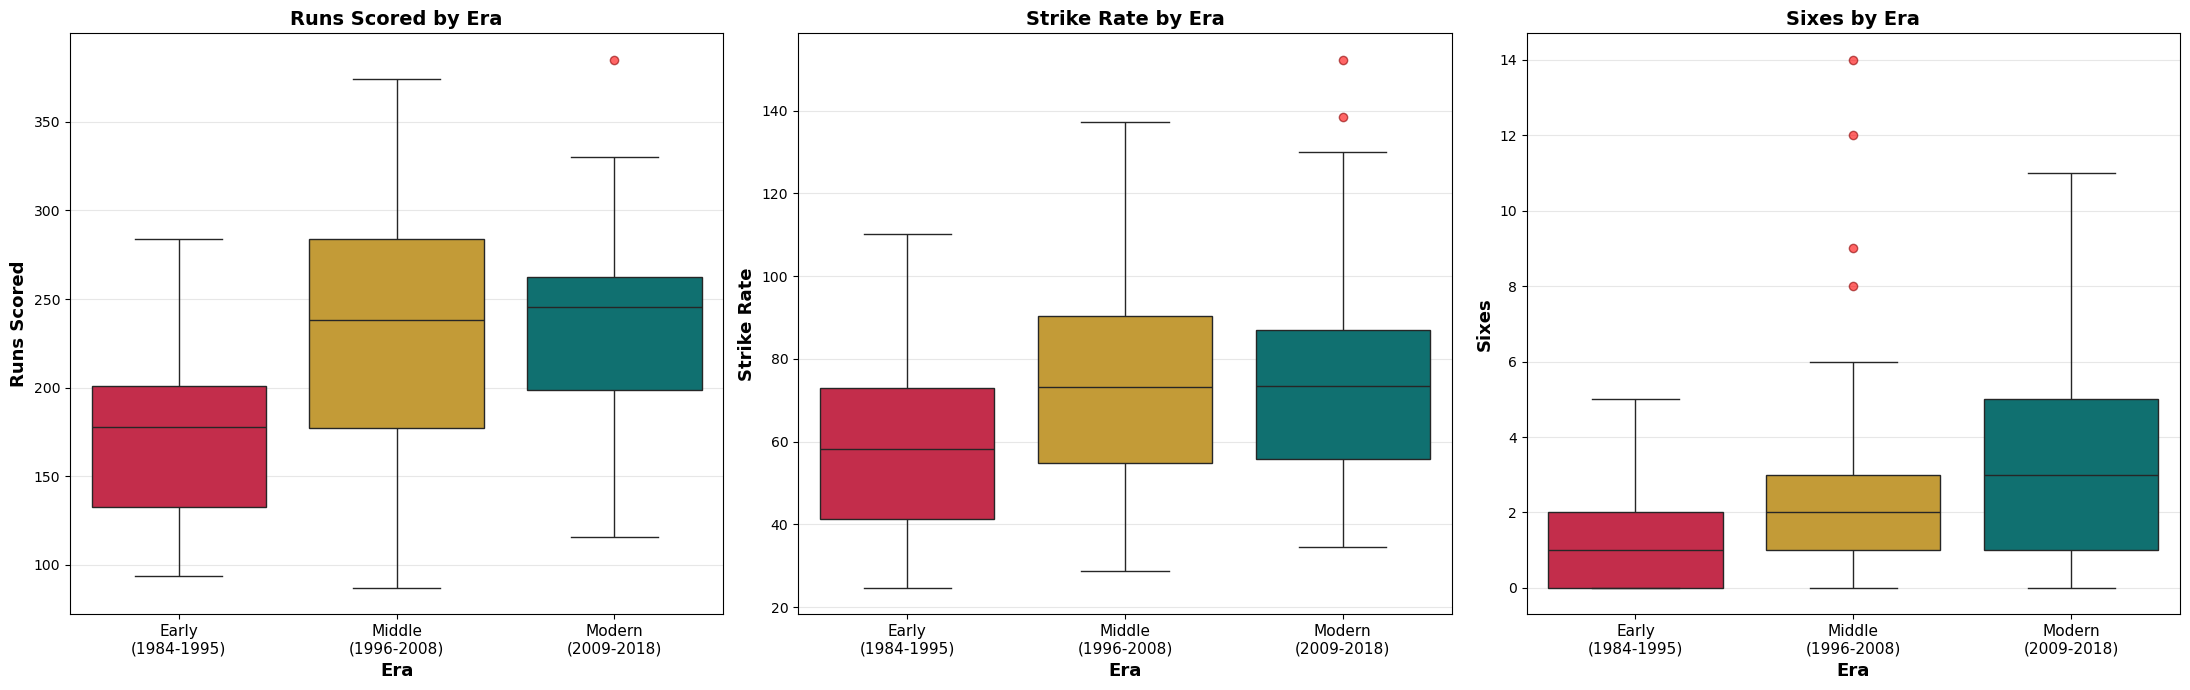


- Runs Scored 
  Early Era (1984-1995)          | Median:    178 | Q1:    132 | Q3:    201 | IQR:     68 | Outliers: None
  Middle Era (1996-2008)         | Median:    238 | Q1:    177 | Q3:    284 | IQR:    106 | Outliers: None
  Modern Era (2009-2018)         | Median:    246 | Q1:    199 | Q3:    262 | IQR:     64 | Outliers: 385

- Strike Rate 
  Early Era (1984-1995)          | Median:     58 | Q1:     41 | Q3:     73 | IQR:     32 | Outliers: None
  Middle Era (1996-2008)         | Median:     73 | Q1:     55 | Q3:     90 | IQR:     36 | Outliers: None
  Modern Era (2009-2018)         | Median:     74 | Q1:     56 | Q3:     87 | IQR:     31 | Outliers: 138, 152

- Sixes 
  Early Era (1984-1995)          | Median:      1 | Q1:      0 | Q3:      2 | IQR:      2 | Outliers: None
  Middle Era (1996-2008)         | Median:      2 | Q1:      1 | Q3:      3 | IQR:      2 | Outliers: 8, 9, 12, 14
  Modern Era (2009-2018)         | Median:      3 | Q1:      1 | Q3:      5 | IQR:      4 |

In [34]:
# Box Plots (Central Tendency & Spread) 
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

flier_style = dict(marker='o', markerfacecolor='red', markersize=6,
                   markeredgecolor='darkred', alpha=0.6)

# Plot 4: Runs Scored
sns.boxplot(data=df_odi_matches, x='Era', y='Run Scored', ax=axes[0],
            palette=era_colors, order=era_order,
            showfliers=True, whis=1.5, flierprops=flier_style)
axes[0].set_xlabel('Era', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Runs Scored', fontsize=13, fontweight='bold')
axes[0].set_title('Runs Scored by Era', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(['Early\n(1984-1995)', 'Middle\n(1996-2008)', 'Modern\n(2009-2018)'], fontsize=11)
axes[0].grid(alpha=0.3, axis='y')

# Plot 5: Strike Rate
sns.boxplot(data=df_odi_matches, x='Era', y='Avg Bat Strike Rate', ax=axes[1],
            palette=era_colors, order=era_order,
            showfliers=True, whis=1.5, flierprops=flier_style)
axes[1].set_xlabel('Era', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Strike Rate', fontsize=13, fontweight='bold')
axes[1].set_title('Strike Rate by Era', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['Early\n(1984-1995)', 'Middle\n(1996-2008)', 'Modern\n(2009-2018)'], fontsize=11)
axes[1].grid(alpha=0.3, axis='y')

# Plot 6: Sixes
sns.boxplot(data=df_odi_matches, x='Era', y='Sixes', ax=axes[2],
            palette=era_colors, order=era_order,
            showfliers=True, whis=1.5, flierprops=flier_style)
axes[2].set_xlabel('Era', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Sixes', fontsize=13, fontweight='bold')
axes[2].set_title('Sixes by Era', fontsize=14, fontweight='bold')
axes[2].set_xticklabels(['Early\n(1984-1995)', 'Middle\n(1996-2008)', 'Modern\n(2009-2018)'], fontsize=11)
axes[2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print IQR and Median for each metric by era
metrics = {
    'Runs Scored': 'Run Scored',
    'Strike Rate': 'Avg Bat Strike Rate',
    'Sixes': 'Sixes'
}

for metric_label, col in metrics.items():
    print(f"\n- {metric_label} ")
    for era in era_order:
        data = df_odi_matches[df_odi_matches['Era'] == era][col]
        q1 = data.quantile(0.25)
        q3 = data.quantile(0.75)
        iqr = q3 - q1
        median = data.median()
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        outliers = data[(data < lower_bound) | (data > upper_bound)]
        outlier_str = ', '.join(str(round(x)) for x in sorted(outliers)) if len(outliers) > 0 else 'None'
        print(f"  {era:30s} | Median: {median:6.0f} | Q1: {q1:6.0f} | Q3: {q3:6.0f} | IQR: {iqr:6.0f} | Outliers: {outlier_str}")

## Box Plot Analysis

### Runs Scored

The box plots confirm and deepen the density story. The **Early Era** has the lowest median (**178 runs**) and a relatively compact spread (IQR: **68**), reflecting the limited and consistent scoring environment of that period. The **Middle Era** shows the greatest volatility - the widest IQR (**106**), a higher median (**238**), and the longest whiskers - suggesting that while teams began scoring more, outcomes were highly match-dependent. The **Modern Era** consolidates this: a slightly higher median (**246**) with a meaningfully tighter IQR (**64**), and notably produces the only runs outlier in the dataset (**385 runs**), confirming that high scores have become the expected baseline while extreme totals are now occasionally possible.

### Strike Rate

The most dramatic improvement in scoring velocity occurred between the **Early and Middle Eras** (median rising from **58** to **73**). From there, median strike rate effectively plateaus - the Modern Era median (**74**) is statistically near-identical to the Middle Era's, and the IQRs are similarly comparable (**36** vs **31**). What the Modern Era adds is not a higher average tempo, but the emergence of **extreme 
individual innings**: outliers at **138** and **152 SR** appear exclusively in the Modern Era, absent from both earlier periods. This suggests evolving batting tactics where certain specialists are deployed specifically for velocity rather than the entire team batting faster.

### Sixes per Match

The central tendency tells a clear story of linear progression: the **Early Era** median sits at **1**, the **Middle Era** at **2**, and the **Modern Era** at **3**. However, the outlier pattern here is counterintuitive - the extreme clusters of **8**, **9**, **12**, and **14 sixes** appear in the **Middle Era**, not the Modern. The Modern Era instead shows a wider IQR (**4** vs **2**), meaning six-hitting has become more *consistently variable* - matches regularly range from low-six to high-six outcomes - rather than producing occasional extreme outliers. This distinction suggests the Middle Era featured sporadic explosive matches, while the Modern Era has normalised power hitting across the board.

## 6. Conclusion


The data describes a two-phase transformation in ODI cricket. The Early-to-Middle transition was the pace-setter: scoring rates rose sharply, strike rates jumped significantly, and boundary-hitting became more deliberate. The Middle-to-Modern transition was the stabiliser: the gains in scoring magnitude were modest, but the consistency with which those standards were met improved markedly. The Modern Era is characterised less by setting new highs than by raising the floor - narrower distributions, tighter interquartile ranges, and higher medians that are reproduced match after match. The exception is sixes, where the Modern Era shows both higher central tendency and greater variance, hinting at the bifurcation of modern batting roles into anchor batters and designated power hitters.
